# Step 5: Model Selection & Training

This notebook documents the full model training pipeline:
- **Naive Baseline** (always predict 0)
- **ML Baseline** (Logistic Regression)
- **XGBoost** (algorithm-level class weighting)
- **LightGBM** (algorithm-level class weighting)

All models are serialized to the `models/` directory after training.

In [1]:
import pandas as pd
import numpy as np
import sys, os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, average_precision_score, ConfusionMatrixDisplay
import xgboost as xgb
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

In [2]:
# --- Load Processed Data ---
# If the full ~1GB CSV is too slow, change nrows to a smaller sample for testing.
# Remove nrows entirely to run on the full 6.3M row dataset.
df = pd.read_csv('../data/processed/processed_transactions.csv')
print(f'Loaded shape: {df.shape}')

y = df['isFraud']
X = df.drop(columns=['isFraud'])
print(f'Fraud rate: {y.mean()*100:.4f}%')

Loaded shape: (6362620, 12)
Fraud rate: 0.1291%


## 1. Data Splitting (80/20 Stratified)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_weight = float(neg / pos)

print(f'Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows')
print(f'scale_pos_weight = {scale_weight:.2f} (Negatives / Positives)')

Train: 5,090,096 rows | Test: 1,272,524 rows
scale_pos_weight = 773.75 (Negatives / Positives)


## 2. Naive Baseline

In [4]:
y_naive = np.zeros(len(y_test), dtype=int)
print('--- Naive Baseline (Predict All Legitimate) ---')
print(classification_report(y_test, y_naive))

--- Naive Baseline (Predict All Legitimate) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.00      0.00      0.00      1643

    accuracy                           1.00   1272524
   macro avg       0.50      0.50      0.50   1272524
weighted avg       1.00      1.00      1.00   1272524



## 3. ML Baseline — Logistic Regression

In [5]:
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print('--- Logistic Regression Baseline ---')
print(classification_report(y_test, y_pred_lr))
print(f'PR AUC: {average_precision_score(y_test, y_prob_lr):.4f}')

--- Logistic Regression Baseline ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.89      0.46      0.60      1643

    accuracy                           1.00   1272524
   macro avg       0.94      0.73      0.80   1272524
weighted avg       1.00      1.00      1.00   1272524

PR AUC: 0.6464


## 4. XGBoost Weighted Classifier

In [6]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_weight,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print('--- XGBoost ---')
print(classification_report(y_test, y_pred_xgb))
print(f'PR AUC: {average_precision_score(y_test, y_prob_xgb):.4f}')

--- XGBoost ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.85      0.99      0.92      1643

    accuracy                           1.00   1272524
   macro avg       0.93      1.00      0.96   1272524
weighted avg       1.00      1.00      1.00   1272524

PR AUC: 0.9868


## 5. LightGBM Weighted Classifier

In [7]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1
)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

print('--- LightGBM ---')
print(classification_report(y_test, y_pred_lgb))
print(f'PR AUC: {average_precision_score(y_test, y_prob_lgb):.4f}')

[LightGBM] [Info] Number of positive: 6570, number of negative: 5083526
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.151124 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1793
[LightGBM] [Info] Number of data points in the train set: 5090096, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001291 -> initscore=-6.651247
[LightGBM] [Info] Start training from score -6.651247
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

## 6. Confusion Matrices (Side-by-Side Comparison)

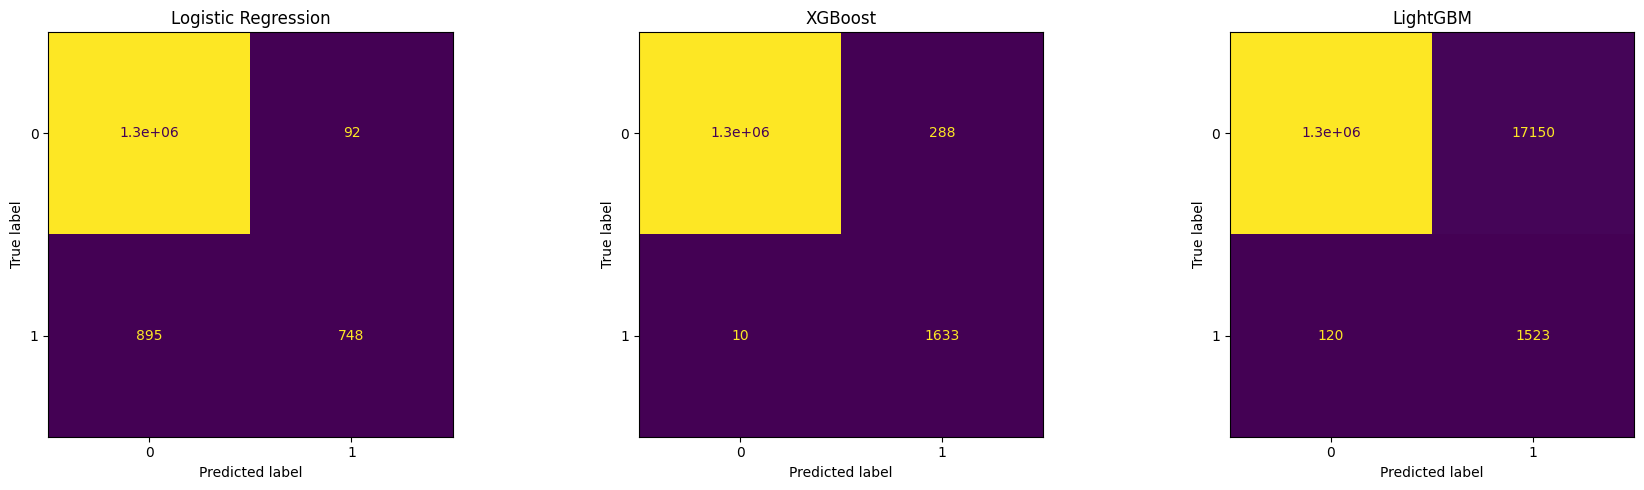

Saved to reports/figures/confusion_matrices.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model, pred, name in zip(
    axes,
    [lr, xgb_model, lgb_model],
    [y_pred_lr, y_pred_xgb, y_pred_lgb],
    ['Logistic Regression', 'XGBoost', 'LightGBM']
):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/confusion_matrices.png')
plt.show()
print('Saved to reports/figures/confusion_matrices.png')

## 7. Save All Models

In [ ]:
os.makedirs('../models', exist_ok=True)
joblib.dump(lr,        '../models/baseline_logreg.pkl')
joblib.dump(xgb_model, '../models/xgboost_model.pkl')
joblib.dump(lgb_model, '../models/lightgbm_model.pkl')
print('All models saved to models/')